
  # Classical Machine Learning  | Classification: Training and Testing

 Group Submission [   GesturePhaseSegmentationProcessed
 ]

## **Section (1) :  Data Preprocess**

### **1. Setup**

In [ ]:
pip install openml

In [ ]:

#  imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml
import sklearn
from sklearn.datasets import fetch_openml   # to load the dataset from the openml
from sklearn.model_selection import train_test_split   # tosplit the data
from sklearn.preprocessing import StandardScaler, LabelEncoder  # for converting the phases (target) to int.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # for random forest algorithm
from sklearn.model_selection import GridSearchCV  #tuning the parameters using GridSearchCV
from sklearn.metrics import classification_report  # getting classification report
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay   #for mertics
import xgboost as xgb #import the xgboost library
#For Logistic Regression & SVM
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
##
from sklearn.ensemble import AdaBoostClassifier

from sklearn.tree import DecisionTreeClassifier


### **2. Load Dataset**

In [ ]:
# loading the dataset from openmal using the code provided in canvas docu [1]

dataset = fetch_openml(data_id=4538, as_frame=False)

print(dataset)


{'data': array([[-5.00942e-03, -9.63710e-04,  5.72770e-04, ...,  9.63100e-04,
         9.16400e-05,  4.38310e-04],
       [ 4.90517e-03,  1.20913e-03, -6.48600e-04, ...,  3.31860e-04,
         1.23000e-05,  4.32710e-04],
       [-2.39286e-03, -2.15880e-04,  1.36300e-04, ...,  8.51980e-04,
         4.17000e-05,  2.01530e-04],
       ...,
       [ 3.07408e-03,  7.87019e-03, -9.62140e-04, ...,  7.11700e-05,
         1.69731e-03,  1.11780e-04],
       [ 3.29680e-03,  8.46747e-03, -1.03479e-03, ...,  2.32600e-05,
         1.38730e-04,  1.13470e-04],
       [ 2.04320e-04, -4.04600e-05,  5.77500e-05, ...,  3.69200e-05,
         1.83985e-03,  3.59900e-05]]), 'target': array(['D', 'D', 'D', ..., 'D', 'D', 'D'], dtype=object), 'frame': None, 'categories': {'Phase': ['D', 'H', 'P', 'R', 'S']}, 'feature_names': ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', '

### **3. Features and Target**

In [ ]:
X_np, y_np = dataset.data, dataset.target  #define the target and the features

print("The X_np shape is ", X_np.shape) # the shape of features
print ("  ")
print(" The y_np shape is ", y_np.shape)  # the  shape of the target
print ("  ")
print(" The Features (X_np) type is ", type(X_np))  # datatype of the feaures
print ("  ")
print("The Target (y_np) type is ", type(y_np))  # datatype of the target


The X_np shape is  (9873, 32)
  
 The y_np shape is  (9873,)
  
 The Features (X_np) type is  <class 'numpy.ndarray'>
  
The Target (y_np) type is  <class 'numpy.ndarray'>


### **4. Missing values**

In [ ]:
# detecting if there is missing values

missing_X = np.isnan(X_np).sum()  # for the 32 features

missing_y = pd.isnull(y_np).sum()  # for the y (the phase),  using the pandas  is  easier to figure out if there is missing vallues regardless if it is categorial or not

print(f" missing values in features   : {missing_X}")
print(f" missing values in target  : {missing_y}")

 missing values in features   : 0
 missing values in target  : 0


In [ ]:

pd.Series(y_np ).value_counts()    # counting the number of classes before training the data

,count
S,2950
D,2741
P,2097
R,1087
H,998


### **5. Data Splitting**

In [ ]:
le = LabelEncoder()      # becasue the taret variable is letter , we need to convert it to int. [2]
y_encoded = le.fit_transform(y_np)

####**LabelEncoder** is used for converting the target variable ‘y’ into integers which  only works on the target variable ‘y’ and not on the features ‘X’. Since the target is phase (letters), we need to convert them into numbers using labelencoder [2].



In [ ]:
# training the dataset [3]
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

####We will use 70% of the dataset for training and 30% for testing. The use of random_state=42 ensures reproducibility of the results, meaning that the split will be the same every time the code is run. The use of stratify=y_encoded ensures that the distribution of classes is preserved in the test and training datasets [3].


In [ ]:

pd.Series(y_train).value_counts()
pd.Series(y_test).value_counts()  # counting the number of classes after  training the data

,count
4,885
0,822
2,629
3,326
1,300


In [ ]:
total_samples = X_np.shape[0]  #checking the features  before split
train_samples = X_train.shape[0]  # cehck for train samples
test_samples = X_test.shape[0]   # cehck for the testing samples

print(f"total samples : {total_samples}")
print(f"training samples (70% ): {train_samples}")
print(f"testing samples (30% ): {test_samples}")

total samples : 9873
training samples (70% ): 6911
testing samples (30% ): 2962


 ### **6. Binarise labels for ROC**

In [ ]:
n_classes = len(np.unique(y_encoded)) # define n_classes before use

def binarize_for_roc(y_vec, n_classes: int):

    Yb = label_binarize(y_vec, classes=np.arange(n_classes))
    if n_classes == 2:
        Yb = np.hstack([1 - Yb, Yb])
    return Yb

Y_test_bin = binarize_for_roc(y_test, n_classes)

### **7. Standardising**

####StandardScaler scales the features by subtracting the mean and scaling to unit variance. It scales each feature individually using the formula :  z = (x - u) / σ . Standardization is a significant step for several machine learning algorithms, like SVMs and linear models with a regularization term, since features of different scales might influence the learning process [4].



In [ ]:
# standardising
#for SVM,  Logistic Regression, KNN [4]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # for the features training
X_test_scaled = scaler.transform(X_test)  #for the testing


print(f"training set size: {X_train_scaled.shape[0]}")
print(f"testing set size: {X_test_scaled.shape[0]}")

training set size: 6911
testing set size: 2962


## **Section (2) : Algorithms**

**To complete the categorisation assignment, we will use eight distinct approaches. These will consist of:**
1. Decision trees
2. logistic regression
3. AdaBoost
4. Random Forest  
5. SVM (Support Vector Machine)
6. Gradient Boosting
7. XGBoost
8. K-Nearest Neighbours

###  **1. Decision Tree**

A Decision Tree is a supervised machine learning algorithm that can be used for both classification and regression tasks. For this assignment, it is used to classify the Gesture Phase Segmentation dataset into more than one class. The model works by splitting the data into smaller groups based on feature values. At each step, the algorithm selects the best feature that separates the classes most effectively. This process goes on until a stopping condition is met, making a tree-like shape.
Each internal node stands for a choice made based on a feature, each branch stands for the result of that choice, and each leaf node stands for the final class prediction.

You can control overfitting with important hyperparameters like max_depth, min_samples_split, and min_samples_leaf in Decision Trees. Because the dataset has a lot of gesture classes and is a little unbalanced, the Decision Tree's performance will be measured with Balanced Accuracy and ROC AUC metrics. GridSearchCV will be used to systematically tune key hyperparameters, such as max_depth (which controls the depth of the tree), min_samples_split (the minimum number of samples needed to split a node), min_samples_leaf (the minimum number of samples needed at a leaf node), and criterion (which measures the quality of a split, such as gini or entropy). This will help the model work better and avoid overfitting. The model that did the best in GridSearchCV will then be tested on a new set of data that it hasn't seen before.

In [ ]:


# create a basic Decision Tree model with a fixed random state
dt = DecisionTreeClassifier(random_state=42)


# create a machine learning pipeline

dt_pipe = Pipeline([

    # handle missing values in the dataset

    ("imputer", SimpleImputer(strategy="median")),

    ("scaler", StandardScaler()),  # kept for consistency

    ("clf", DecisionTreeClassifier(random_state=42))
])

# GridSearch will try all combinations to find the best performing model
dt_param_grid = {
    # Maximum depth of the decision tree
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__criterion": ["gini", "entropy"]
}


dt_grid = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)


dt_grid.fit(X_train, y_train)

print("Best DT params:", dt_grid.best_params_)
print("Best DT CV balanced acc:", dt_grid.best_score_)

Best DT params: {'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5}
Best DT CV balanced acc: 0.4586706863340188


In [ ]:

dt_grid = GridSearchCV(              #Grid Search
    dt_pipe,
    dt_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

# GridSearchCV will train many models with different parameters

dt_grid.fit(X_train, y_train)

print("Best DT params:", dt_grid.best_params_)
print("Best DT CV balanced acc:", dt_grid.best_score_)

Best DT params: {'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5}
Best DT CV balanced acc: 0.4586706863340188


### **1.1 Evaluation**

### **1.1.1 Balanced Accuracy (DT)**

In [ ]:
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
# The model predicts the class label for each sample in X_test


#the Balanced Accuracy score
bal_acc_dt = balanced_accuracy_score(y_test, y_pred_dt)
print("Balanced Accuracy (Decision Tree):", bal_acc_dt)

Balanced Accuracy (Decision Tree): 0.47340207838031506


## **1.1.2 Confusion Matrix**

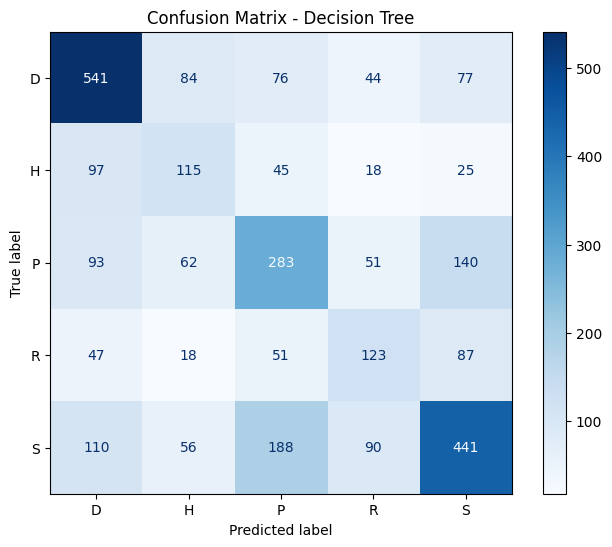

In [ ]:
# create a figure and axis for the confusion matrix plot
fig, ax = plt.subplots(figsize=(8,6))

# display the confusion matrix using the true labels and predicted labels
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=le.classes_,
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix - Decision Tree")
plt.grid(False)
plt.show()

## **1.1.3 Roc AUC (Macro + Micro)**

In [ ]:
# predict the probability of each class for the test dataset
y_proba_dt = dt_best.predict_proba(X_test)

# calculate ROC AUC using macro averaging
roc_macro_dt = roc_auc_score(y_test, y_proba_dt, multi_class="ovr", average="macro")

# calculate ROC AUC using micro averaging
roc_micro_dt = roc_auc_score(y_test, y_proba_dt, multi_class="ovr", average="micro")

print("ROC AUC Macro (Decision Tree):", roc_macro_dt)
print("ROC AUC Micro (Decision Tree):", roc_micro_dt)

ROC AUC Macro (Decision Tree): 0.6947590576282504
ROC AUC Micro (Decision Tree): 0.7147782843316719


### **1.1.4 Decision Tree - Micro average ROC**

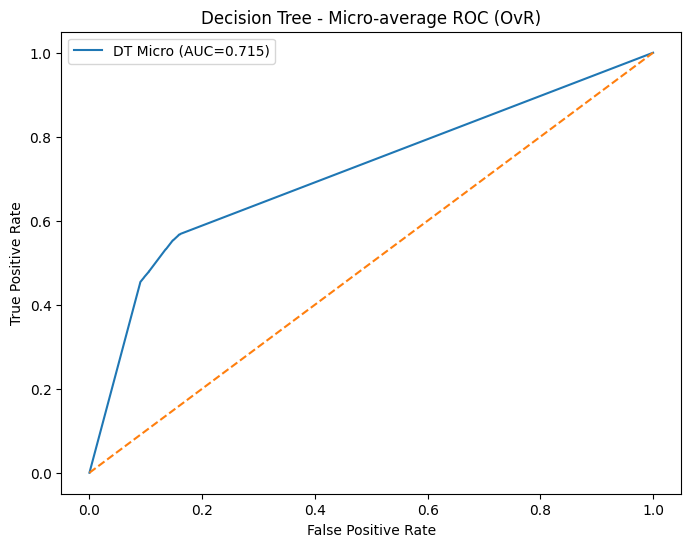

In [ ]:
# no. of classes in the dataset
n_classes = len(le.classes_)
# convert the true labels into binary format for ROC calculation
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
fpr_dt, tpr_dt, _ = roc_curve(y_test_bin.ravel(), y_proba_dt.ravel())
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f"DT Micro (AUC={auc_dt:.3f})")
plt.plot([0,1],[0,1],"--")
plt.title("Decision Tree - Micro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### **1.1.5 Decision Tree - Macro-average ROC**

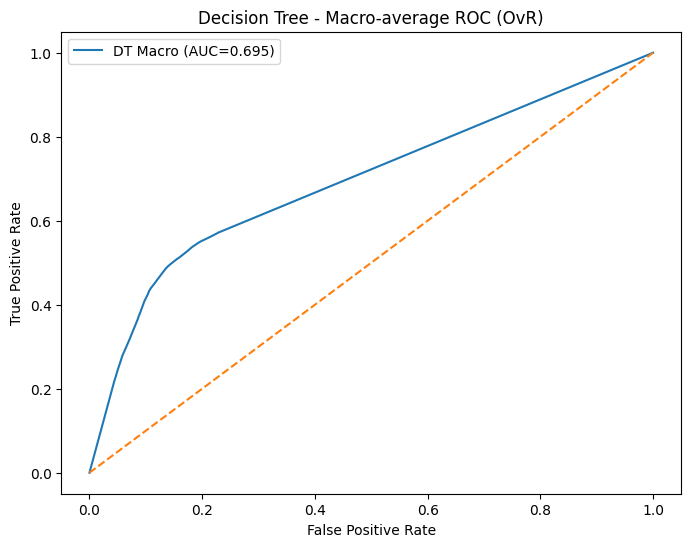

In [ ]:
# for each class separately
fpr_list_dt, tpr_list_dt = [], []
for i in range(n_classes):
  # Compute ROC curve for the current class
    # y_test_bin[:, i] -> true labels for class i
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_dt[:, i])
    fpr_list_dt.append(fpr_i)
    tpr_list_dt.append(tpr_i)

all_fpr_dt = np.unique(np.concatenate(fpr_list_dt))
mean_tpr_dt = np.zeros_like(all_fpr_dt)

for i in range(n_classes):
    mean_tpr_dt += np.interp(all_fpr_dt, fpr_list_dt[i], tpr_list_dt[i])

mean_tpr_dt /= n_classes

auc_dt_macro = auc(all_fpr_dt, mean_tpr_dt)

# Plot the Macro-Average ROC curve
plt.figure(figsize=(8,6))
plt.plot(all_fpr_dt, mean_tpr_dt, label=f"DT Macro (AUC={auc_dt_macro:.3f})")
plt.plot([0,1],[0,1],"--")
plt.title("Decision Tree - Macro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## **2. Logistic Regression**



Logistic Regression is a supervised machine learning algorithm commonly used for classification tasks. Despite its name, it is a classification model rather than a regression model. It predicts the probability that an input sample belongs to a particular class using the logistic (sigmoid) function, which maps predicted values to a range between 0 and 1. For multi-class classification problems, Logistic Regression uses strategies such as One-vs-Rest (OvR), where a separate classifier is trained for each class against all other classes. The model learns a linear decision boundary by estimating coefficients for each feature using maximum likelihood estimation. Logistic Regression is computationally efficient, easy to interpret, and works well when the relationship between features and the target is approximately linear. However, its performance may decrease when the data is highly non-linear.

GridSearchCV is applied to Logistic Regression to identify the optimal hyperparameters such as the regularization strength parameter (C) and solver type. By evaluating combinations of parameters using cross-validation and a scoring metric (balanced accuracy), the algorithm selects the configuration that produces the best generalization performance on unseen data.

In [ ]:
# Use a pipeline to combine preprocessing and training,
lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000))
])

# Set the hyperparameters to tune.

lr_param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],

    "clf__solver": ["lbfgs", "saga"],
    "clf__penalty": ["l2"]
}

# GridSearchCV performs 5-fold cross-validation
lr_grid = GridSearchCV(
    lr_pipe,
    lr_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)
print("Best Logistic Regression parameters:", lr_grid.best_params_)

print("Best Logistic Regression CV balanced accuracy:", lr_grid.best_score_)

Best Logistic Regression parameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Best Logistic Regression CV balanced accuracy: 0.36366162132641916


##2.1 Evaluation

##2.1.1 Balanced Accuracy (LR)

In [ ]:
# using best estimator
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test)
# Calculate Balanced Accuracy.
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)
print("Balanced Accuracy (Logistic Regression):", bal_acc_lr)

Balanced Accuracy (Logistic Regression): 0.35817553816516484


##2.1.2  Confusion Matrix (LR)


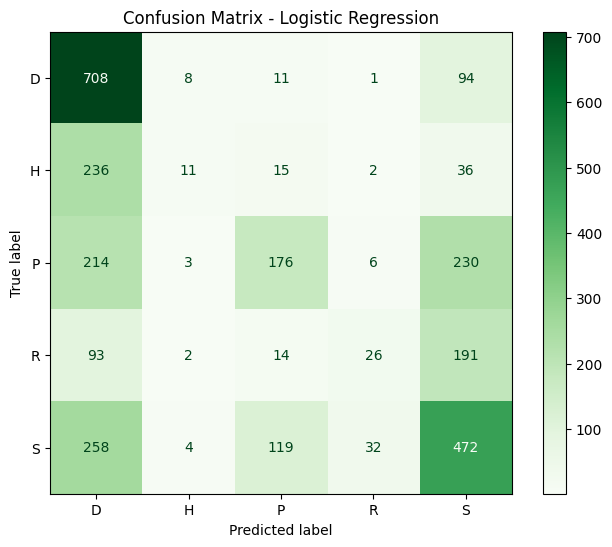

In [ ]:
# Create a figure and axis.
fig, ax = plt.subplots(figsize=(8,6))
# Use original class names for display.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=le.classes_,
    cmap="Greens",
    ax=ax
)
plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.show()

##2.1.3 ROC AUC (Macro + Micro)




In [ ]:
#  calculate the ROC AUC score.
y_proba_lr = lr_best.predict_proba(X_test)
# Compute the macro-average ROC AUC using One-vs-Rest.
roc_macro_lr = roc_auc_score(
    y_test,
    y_proba_lr,
    multi_class="ovr",
    average="macro"
)
# Compute the micro-average ROC AUC score.
roc_micro_lr = roc_auc_score(
    y_test,
    y_proba_lr,
    multi_class="ovr",
    average="micro"
)
print("ROC AUC Macro (Logistic Regression):", roc_macro_lr)
print("ROC AUC Micro (Logistic Regression):", roc_micro_lr)

ROC AUC Macro (Logistic Regression): 0.7598683110649068
ROC AUC Micro (Logistic Regression): 0.7886636080426341


## 2.1.4 Logistic Regression — Micro-average ROC

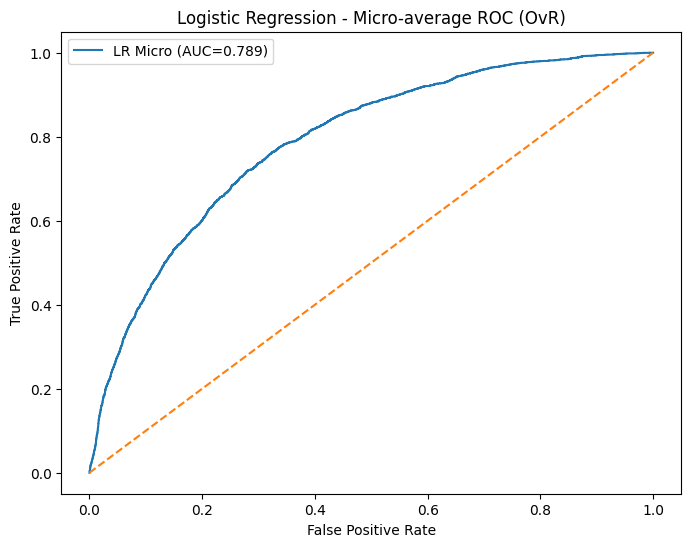

In [ ]:
# Get the number of classes in the dataset.
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
# Compute the micro-average ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin.ravel(), y_proba_lr.ravel())
# Compute the AUC for the micro-average ROC curve.
auc_lr = auc(fpr_lr, tpr_lr)
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"LR Micro (AUC={auc_lr:.3f})")
plt.plot([0,1], [0,1], "--")
plt.title("Logistic Regression - Micro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 2.1.5 Logistic Regression — Macro-average ROC

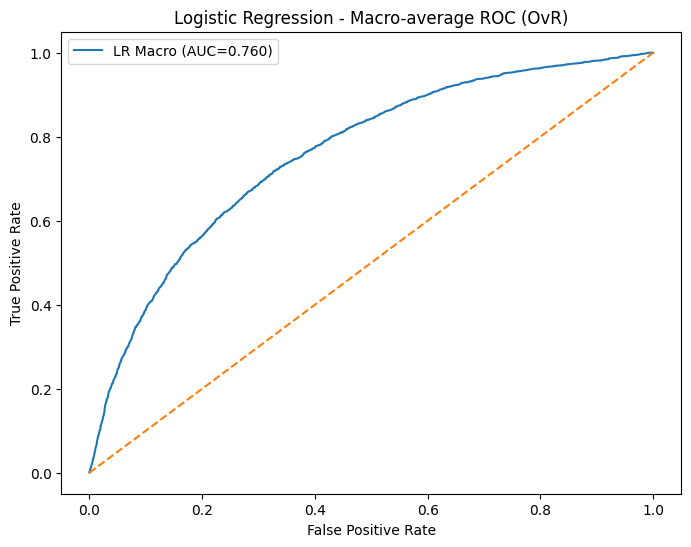

In [ ]:
# create lists to store the FPR and TPR for each class.
fpr_list, tpr_list = [], []
# compute the ROC curve for each class (One-vs-Rest).
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_lr[:, i])
    fpr_list.append(fpr_i)
    tpr_list.append(tpr_i)
all_fpr = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)

# then accumulate the TPR values.
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
mean_tpr /= n_classes
auc_lr_macro = auc(all_fpr, mean_tpr)

# plot the macro-average ROC curve.
plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"LR Macro (AUC={auc_lr_macro:.3f})")
plt.plot([0,1], [0,1], "--")
plt.title("Logistic Regression - Macro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### **3. AdaBoost**

AdaBoost, or Adaptive Boosting, is all about turning a bunch of weak learners into one strong classifier. Here’s how it works. Instead of training models separately like bagging does, boosting lines them up—each new model tries to do better where the last one messed up.

It starts simple: every training example gets the same weight. The first weak learner—usually a small decision tree—learns from this balanced set. After that, AdaBoost looks at which samples got classified wrong and bumps up their weights. Suddenly, these tricky cases matter more in the next round. You keep going like this for as many rounds as you want.

Each weak learner gets a weight based on how well it did. In the end, AdaBoost pulls together all the learners, mixing their predictions based on those weights. The result is a single, much stronger classifier.

By adjusting the focus with each step, AdaBoost zeroes in on the hard cases and keeps pushing down the overall error.

In [ ]:


#Build Pipeline
ada_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),  # kept for consistency
    ("clf", AdaBoostClassifier(random_state=42))
])

In [ ]:
# hyperparameter grid

ada_param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.1, 1]
}
#GridSearchCV
ada_grid = GridSearchCV(
    ada_pipe,
    ada_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

print("Best AdaBoost params:", ada_grid.best_params_)
print("Best AdaBoost CV balanced acc:", ada_grid.best_score_)

Best AdaBoost params: {'clf__learning_rate': 1, 'clf__n_estimators': 200}
Best AdaBoost CV balanced acc: 0.3906859220882237


### 3.1 Evaluation

### 3.1.1 Balanced Accuracy

In [ ]:
# Get the best AdaBoost model found during GridSearchCV
ada_best = ada_grid.best_estimator_
y_pred_ada = ada_best.predict(X_test)

# Calculate Balanced Accuracy
bal_acc_ada = balanced_accuracy_score(y_test, y_pred_ada)
print("Balanced Accuracy (AdaBoost):", bal_acc_ada)

Balanced Accuracy (AdaBoost): 0.39065844844963415


### 3.1.2 Confusion Matrix

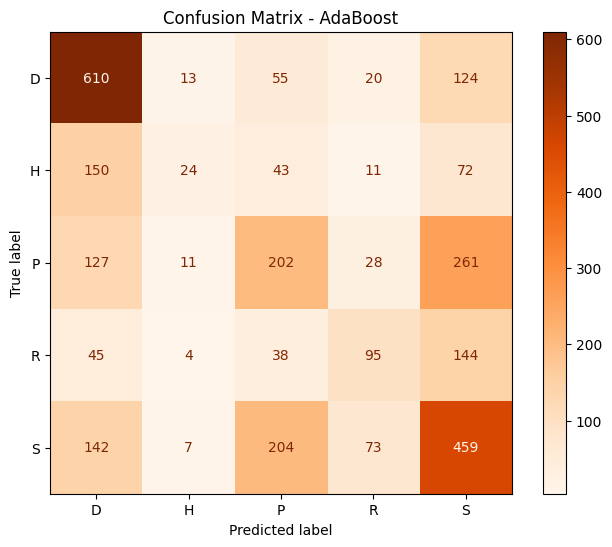

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

# Generate the confusion matrix from the true and predicted labels
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ada,
    display_labels=le.classes_,
    cmap="Oranges",
    ax=ax
)

plt.title("Confusion Matrix - AdaBoost")
# Remove grid lines for cleaner visualisation
plt.grid(False)
plt.show()

### 3.1.3 ROC AUC (Macro + Micro)

In [ ]:
# Predict probability scores for each class using the AdaBoost model
y_proba_ada = ada_best.predict_proba(X_test)

# Compute ROC-AUC score using macro averaging
roc_macro_ada = roc_auc_score(y_test, y_proba_ada, multi_class="ovr", average="macro")
# Compute ROC-AUC score using micro averaging
roc_micro_ada = roc_auc_score(y_test, y_proba_ada, multi_class="ovr", average="micro")
print("ROC AUC Macro (AdaBoost):", roc_macro_ada)
print("ROC AUC Micro (AdaBoost):", roc_micro_ada)

ROC AUC Macro (AdaBoost): 0.766368528920817
ROC AUC Micro (AdaBoost): 0.7963077555404696


### 3.1.4 Micro-average ROC

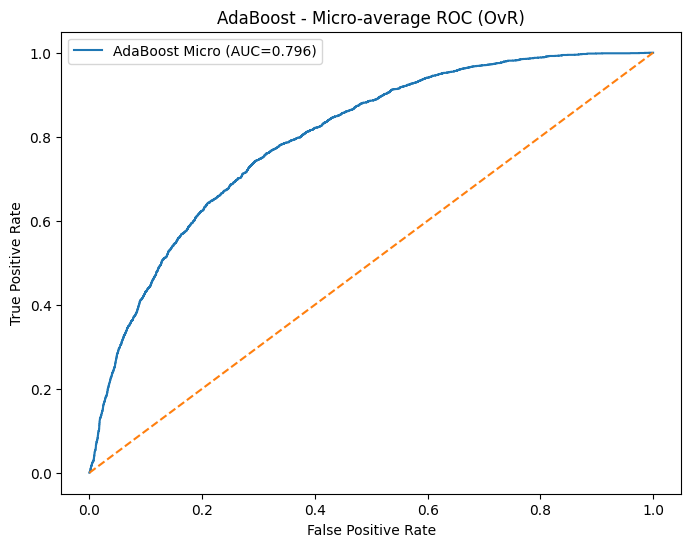

In [ ]:
# Get number of classes from label encoder
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr_ada, tpr_ada, _ = roc_curve(y_test_bin.ravel(), y_proba_ada.ravel())
# Calculate the Area Under the Curve (AUC)
auc_ada = auc(fpr_ada, tpr_ada)
# Create the ROC plot
plt.figure(figsize=(8,6))
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost Micro (AUC={auc_ada:.3f})") # Plot ROC curve
plt.plot([0,1],[0,1],"--") # Plot reference line for random classifier
plt.title("AdaBoost - Micro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### 3.1.5 Macro-average ROC

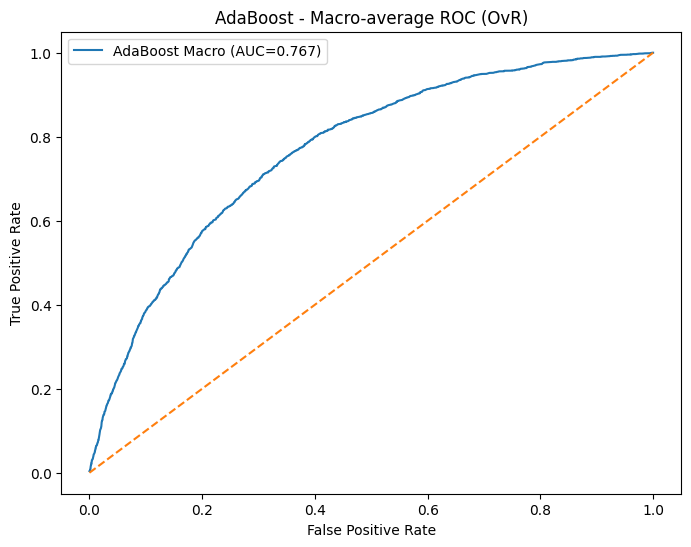

In [ ]:
fpr_list_ada, tpr_list_ada = [], []
#Compute ROC curve for each class
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_ada[:, i])
    fpr_list_ada.append(fpr_i)
    tpr_list_ada.append(tpr_i)

all_fpr_ada = np.unique(np.concatenate(fpr_list_ada))
mean_tpr_ada = np.zeros_like(all_fpr_ada)

for i in range(n_classes):
    mean_tpr_ada += np.interp(all_fpr_ada, fpr_list_ada[i], tpr_list_ada[i])
    # Interpolate TPR for common FPR values
# Average the TPR values across all classes
mean_tpr_ada /= n_classes

auc_ada_macro = auc(all_fpr_ada, mean_tpr_ada)

plt.figure(figsize=(8,6))
plt.plot(all_fpr_ada, mean_tpr_ada, label=f"AdaBoost Macro (AUC={auc_ada_macro:.3f})")
plt.plot([0,1],[0,1],"--") # Plot baseline random classifier line
plt.title("AdaBoost - Macro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 4. Random Forest



#### **Random Forest** is a type of ensemble learning algorithm that consists of a large number of decision trees. These trees are used for classification, regression, and feature selection. Each tree is trained on a random sample of the data (using a bootstrap method), and at each node, a random subset of the features is selected. For a classification problem, the output is the class with the most votes across all trees, while for regression, it is the average of the predictions made by individual trees. Random Forests are robust to outliers, can handle high-dimensional data, support both numeric and categorical features, and do not require feature scaling [5].

### GridSearchCV is a powerful class in the scikit-learn library used for hyperparameter tuning of a machine learning model by performing a grid search over a predefined range of values for the parameters of the model. It uses a scoring metric and cross-validation to determine the parameters of the model that yield the best performance. The major components of the GridSearchCV class include the estimator, the parameters, the scoring metric, and the cross-validation mechanism [6].


In [ ]:

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(rf, param_grid, cv=5, scoring='balanced_accuracy')

rf_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 200]},
             scoring='balanced_accuracy')

In [ ]:
# using the  GridSearchCV   [8] [9]
rf_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 200]},
             scoring='balanced_accuracy')

In [ ]:
print(f"Best Hyperparameters: {rf_grid.best_params_}")   #the best parameters found [9]

Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}


In [ ]:
print(f"Best Cross-Validation Accuracy: {rf_grid.best_score_:.4f}")   #  the best accuracy score the model gives [9]

Best Cross-Validation Accuracy: 0.5643


In [ ]:
rf_best = rf_grid.best_estimator_  #[9]
y_pred_rf = rf_best.predict(X_test_scaled)
y_proba_rf = rf_best.predict_proba(X_test_scaled)


In [ ]:

print("Classification Report:") #  [10]
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.88      0.77       822
           1       0.85      0.39      0.53       300
           2       0.67      0.49      0.57       629
           3       0.69      0.42      0.52       326
           4       0.63      0.78      0.70       885

    accuracy                           0.67      2962
   macro avg       0.70      0.59      0.62      2962
weighted avg       0.68      0.67      0.65      2962



In [ ]:
rf_default = RandomForestClassifier(random_state=42) #  a default Random Forest Classifier
rf_default.fit(X_train_scaled, y_train)

default_rf_acc = rf_default.score(X_test_scaled, y_test)    #without using the  GridSearchCV
optimal_rf_acc = rf_best.score(X_test_scaled, y_test)        # with using the  GridSearchCV

print(f"rf default accuracy: {default_rf_acc:.4f}")
print(f" rf  optimal accuracy:   {optimal_rf_acc:.4f}")

rf default accuracy: 0.6590
 rf  optimal accuracy:   0.6691


## 4. 1  Evaluation

### 4.1.1. Balanced Accuracy

#### Random Forest can handle class imbalance problems, but measuring with accuracy may not always be correct, especially when some classes may be underrepresented. Balanced accuracy calculates the average recall across classes, where each class is considered equally important [11].


In [ ]:
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf) # evaluating the model
print("Balanced Accuracy for rf", bal_acc_rf )


Balanced Accuracy for rf 0.5939056450096036


### 4.1.2. confusion_matrix

#### A confusion matrix is a table used to compare the predictions of a classification model with the actual results. It is used to check the accuracy of the classification model. The table is divided into four categories: true positives and true negatives, which are correct predictions, and false positives and false negatives, which are incorrect predictions. The false positives are also known as Type I errors, and the false negatives are known as Type II errors. The confusion matrix is used to check the efficiency of the classification model and is used to improve the model [12].


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)   #[13]
print( " confusion_matrix for rf", "\n", cm_rf)

 confusion_matrix for rf 
 [[724   6  19  15  58]
 [105 117  28   9  41]
 [114   9 309  19 178]
 [ 34   3  24 138 127]
 [ 88   3  80  20 694]]


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=le.classes_, cmap='Blues', ax=ax)
plt.title(" Confusion Matrix-  Random Forest")
plt.grid(False)
plt.show()

### 4.1.3. ROC auc Metrics


### The ROC curve is a plot that illustrates the performance of a classification model at various thresholds by using the true positive rate versus the false positive rate. It can be used to assess the capability of a classification model to separate classes. The area under the ROC curve (AUC) is used to determine the effectiveness of the model in ranking positive instances above negative ones. A perfect model is indicated by an AUC of 1.0, which means that it is able to distinguish completely between positive and negative instances [14].



In [ ]:
roc_macro_rf = roc_auc_score(y_test, y_proba_rf, multi_class='ovr', average='macro')  # [15]  # evaluating the model micro and macro auc roc
roc_micro_rf = roc_auc_score(y_test, y_proba_rf, multi_class='ovr', average='micro')
print(f"ROC AUC _ Macro :   {roc_macro_rf:.4f}")
print(f"ROC AUC _ Micro :   {roc_micro_rf:.4f}")

ROC AUC _ Macro :   0.8941
ROC AUC _ Micro :   0.9032


## 5.  Support Vector Machine (SVM)



Support Vector Machine (SVM) is a supervised machine learning algorithm used for both classification and regression tasks, but it is primarily known for classification. SVM works by finding an optimal hyperplane that separates data points of different classes with the maximum possible margin. The data points closest to the decision boundary are called support vectors, and they play a crucial role in defining the position of the hyperplane. For datasets that are not linearly separable, SVM uses kernel functions such as linear and radial basis function (RBF) kernels to transform the data into a higher-dimensional space where separation becomes possible. SVM is effective in high-dimensional spaces, robust to overfitting, and performs well when there is a clear margin of separation between classes. However, it can be computationally expensive on very large datasets.

GridSearchCV is used with SVM to tune important hyperparameters including the penalty parameter (C), kernel type, and kernel coefficient (gamma). Through cross-validation, GridSearchCV evaluates multiple combinations of parameters and selects the model that achieves the best balanced accuracy score, ensuring improved classification performance and better generalization.

In [ ]:
# build a pipeline with preprocessing + SVM

svm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
     # SVM is sensitive to feature scaling.
    ("scaler", StandardScaler()),
    ("clf", SVC(probability=True))
])

# GridSearch
svm_param_grid = {

    "clf__C": [0.1, 1, 10],

    "clf__kernel": ["linear", "rbf"],
    "clf__gamma": ["scale", "auto"]
}

# to select the best hyperparameter combination.

svm_grid = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM parameters:", svm_grid.best_params_)
print("Best SVM CV balanced accuracy:", svm_grid.best_score_)

Best SVM parameters: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best SVM CV balanced accuracy: 0.46350844907842664


## 5.1 Evaluation  

##  5.1.1 Balanced Accuracy (SVM)

In [ ]:
#  retrieve the best SVM model
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test)

#  Balanced Accuracy.
bal_acc_svm = balanced_accuracy_score(y_test, y_pred_svm)
print("Balanced Accuracy (SVM):", bal_acc_svm)

Balanced Accuracy (SVM): 0.4692792914940159


## 5.1.2  Confusion Matrix (SVM)

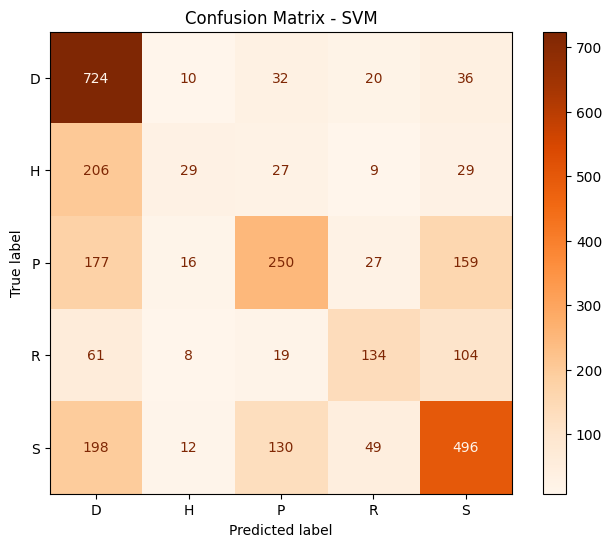

In [ ]:
#  a figure and axis for the confusion matrix.
fig, ax = plt.subplots(figsize=(8,6))

#  original class names instead of encoded values.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=le.classes_,
    cmap="Oranges",
    ax=ax
)
plt.title("Confusion Matrix - SVM")
plt.grid(False)

#  the confusion matrix.
plt.show()

## 5.1.3 ROC AUC (Macro + Micro) (SVM)

In [ ]:
#  predicted class probabilities from the SVM model.
y_proba_svm = svm_best.predict_proba(X_test)

#  macro-average ROC AUC.
roc_macro_svm = roc_auc_score(
    y_test,
    y_proba_svm,
    multi_class="ovr",
    average="macro"
)

#  micro-average ROC AUC.
roc_micro_svm = roc_auc_score(
    y_test,
    y_proba_svm,
    multi_class="ovr",
    average="micro"
)

#  the final ROC AUC results for the SVM model.
print("ROC AUC Macro (SVM):", roc_macro_svm)
print("ROC AUC Micro (SVM):", roc_micro_svm)

ROC AUC Macro (SVM): 0.8086710743727814
ROC AUC Micro (SVM): 0.8334048179939373


## 5.1.4 SVM — Micro-average ROC

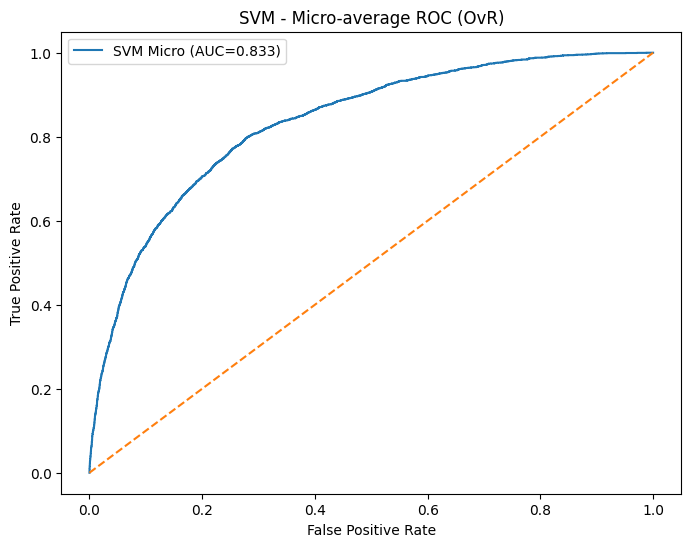

In [ ]:
#  the micro-average ROC curve for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin.ravel(), y_proba_svm.ravel())

#  the AUC, which summarizes overall classifier performance.
auc_svm = auc(fpr_svm, tpr_svm)
plt.figure(figsize=(8,6))

plt.plot(fpr_svm, tpr_svm, label=f"SVM Micro (AUC={auc_svm:.3f})")

plt.plot([0,1], [0,1], "--")
plt.title("SVM - Micro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 5.1. 5 SVM — Macro-average ROC




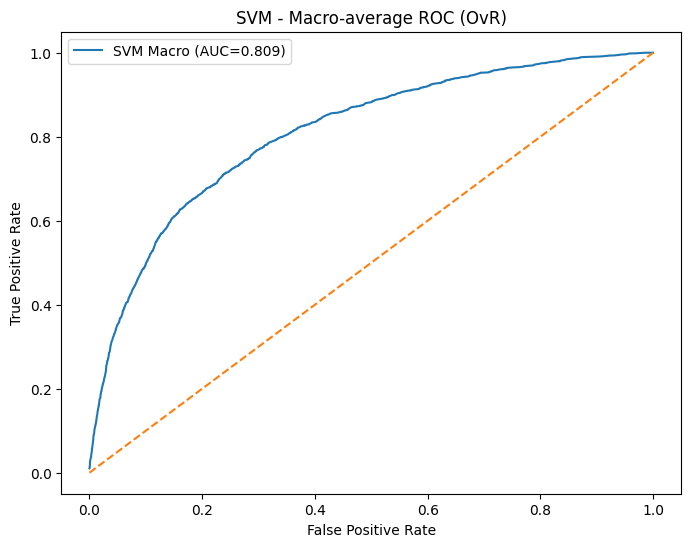

In [ ]:
#  lists to store FPR and TPR for each class.
fpr_list, tpr_list = [], []

for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_svm[:, i])
    fpr_list.append(fpr_i)
    tpr_list.append(tpr_i)

all_fpr = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
mean_tpr /= n_classes
auc_svm_macro = auc(all_fpr, mean_tpr)
plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"SVM Macro (AUC={auc_svm_macro:.3f})")
plt.plot([0,1], [0,1], "--")

plt.title("SVM - Macro-average ROC (OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 6.Gradient Boosting

In [ ]:
# gradient Boosting with hyperparameter tuning (GridSearchCV)

gb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    "clf__n_estimators": [150, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3],
    "clf__subsample": [0.8]
}


gb_grid = GridSearchCV(
    gb_pipe,
    gb_param_grid,
    cv=3,
    scoring="balanced_accuracy",
    n_jobs=1
)

gb_grid.fit(X_train, y_train)
print("Best Params (Gradient Boosting):", gb_grid.best_params_)
print("Best CV Balanced Accuracy (Gradient Boosting):", gb_grid.best_score_)

gb_best = gb_grid.best_estimator_

Best Params (Gradient Boosting): {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Best CV Balanced Accuracy (Gradient Boosting): 0.5167602678326005


# 6.1 Evaluation

In [ ]:
# Predictions and Balanced Accuracy (Gradient Boosting)
y_pred_gb = gb_best.predict(X_test)
bal_acc_gb = balanced_accuracy_score(y_test, y_pred_gb)
print("Balanced Accuracy (Gradient Boosting):", bal_acc_gb)

Balanced Accuracy (Gradient Boosting): 0.5531487782904525


# 6.1.2 Confusion Matrix (Gradient Boosting)

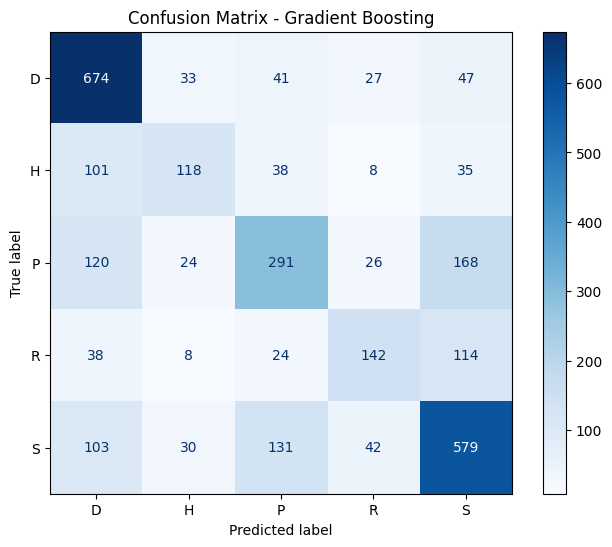

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    display_labels=le.classes_,
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.grid(False)
plt.show()

# 6.1.3 ROC AUC (Macro + Micro) (Gradient Boosting)

In [ ]:
# ROC AUC scores (Gradient Boosting)
y_proba_gb = gb_best.predict_proba(X_test)

roc_macro_gb = roc_auc_score(y_test, y_proba_gb, multi_class="ovr", average="macro")
roc_micro_gb = roc_auc_score(y_test, y_proba_gb, multi_class="ovr", average="micro")

print("ROC AUC Macro (Gradient Boosting):", roc_macro_gb)
print("ROC AUC Micro (Gradient Boosting):", roc_micro_gb)

ROC AUC Macro (Gradient Boosting): 0.8556624388247833
ROC AUC Micro (Gradient Boosting): 0.8727092519197707


# 6.1.4 Gradient Boosting — Micro-average ROC

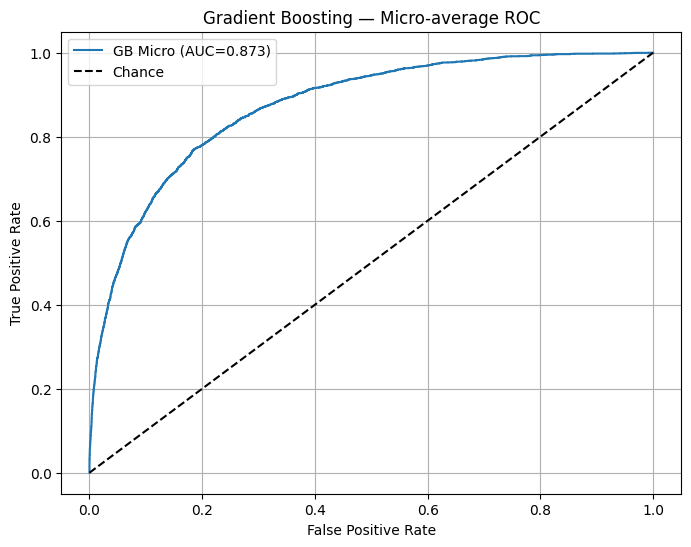

In [ ]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr_gb, tpr_gb, _ = roc_curve(y_test_bin.ravel(), y_proba_gb.ravel())
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8,6))
plt.plot(fpr_gb, tpr_gb, label=f"GB Micro (AUC={auc_gb:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting — Micro-average ROC")
plt.legend()
plt.grid(True)
plt.show()

# 6.1.5 Gradient Boosting — Macro-average ROC

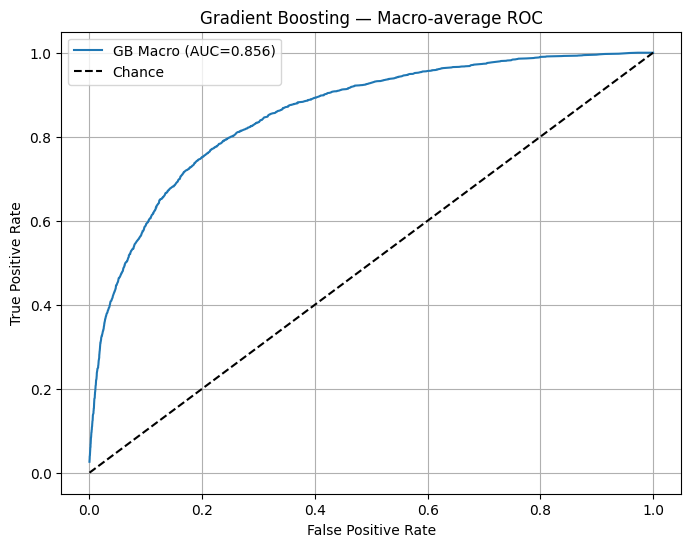

In [ ]:
# Macro-average ROC (Gradient Boosting)
fpr_list, tpr_list = [], []

for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_gb[:, i])
    fpr_list.append(fpr_i)
    tpr_list.append(tpr_i)

all_fpr = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
mean_tpr /= n_classes

macro_auc_gb = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"GB Macro (AUC={macro_auc_gb:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting — Macro-average ROC")
plt.legend()
plt.grid(True)
plt.show()

## **7. XgBoost**


####  In machine learning, traditional models like decision trees and random forests are interpretable but may not work well on complex data. XGBoost, which stands for eXtreme Gradient Boosting, is a more advanced and efficient algorithm that enhances accuracy and speed. It is an optimized version of gradient boosting and functions as an ensemble model by using several weak models to form a stronger and more powerful model [16].


In [ ]:
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')   #hyperparameters


xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6]
}


grid_xgb = GridSearchCV(xgb_clf, xgb_param_grid, cv=5, scoring='balanced_accuracy', n_jobs=-1)  # using the gridsearch as we used it in random forest
grid_xgb.fit(X_train, y_train)





GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 6],
                         'n_estimators': [100, 200]},
             scoring='balanced_accuracy')

In [ ]:
xgb_best = grid_xgb.best_estimator_   # getting thr best parameter for the model

print("Best Hyperparameters:", xgb_best)

Best Hyperparameters: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
print(f"Best Cross-Validation Accuracy: {grid_xgb.best_score_:.4f}") #  the best accuracy score the model gives

Best Cross-Validation Accuracy: 0.5873


In [ ]:
xgb_best = grid_xgb.best_estimator_          # classification report
y_pred_xgb = xgb_best.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.85      0.78       822
           1       0.72      0.48      0.57       300
           2       0.64      0.55      0.60       629
           3       0.65      0.48      0.55       326
           4       0.66      0.77      0.71       885

    accuracy                           0.68      2962
   macro avg       0.68      0.62      0.64      2962
weighted avg       0.68      0.68      0.67      2962



In [ ]:
xgb_best = grid_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)


In [ ]:
xgb_default = RandomForestClassifier(random_state=42) #  a default xgb Classifier
xgb_default.fit(X_train_scaled, y_train)

default_xgb_acc = xgb_default.score(X_test_scaled, y_test)    #without using the  GridSearchCV
optimal_xgb_acc =xgb_best.score(X_test_scaled, y_test)        # with using the  GridSearchCV

print(f"xgb default accuracy: {default_xgb_acc:.4f}")
print(f"  xgb optimal accuracy:   {optimal_xgb_acc:.4f}")

xgb default accuracy: 0.6590
  xgb optimal accuracy:   0.3795


## 7.1 Evaluation

Best Parameters found: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200}
Balanced Accuracy:     0.6242
ROC AUC (Macro-avg):   0.8960
ROC AUC (Micro-avg):   0.9082


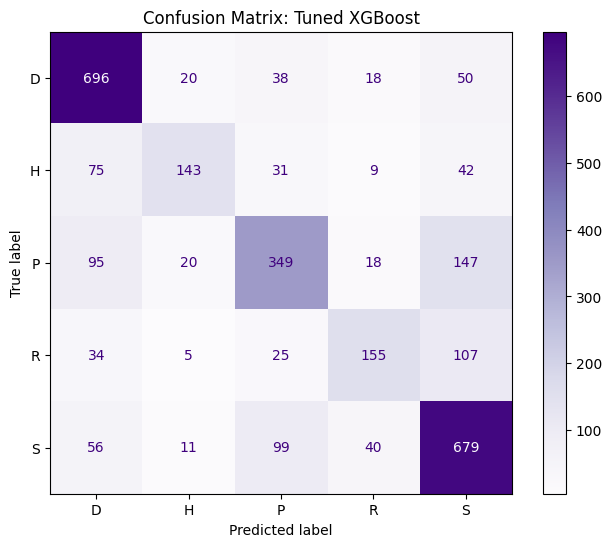

In [ ]:
bal_acc_xgb = balanced_accuracy_score(y_test, y_pred_xgb)            # evaluating the model balance score , micro and macro roc
roc_macro_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='macro')
roc_micro_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='micro')

print(f"Best Parameters found: {grid_xgb.best_params_}")
print(f"Balanced Accuracy:     {bal_acc_xgb:.4f}")
print(f"ROC AUC (Macro-avg):   {roc_macro_xgb:.4f}")
print(f"ROC AUC (Micro-avg):   {roc_micro_xgb:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=le.classes_, cmap='Purples', ax=ax)
plt.title("Confusion Matrix: Tuned XGBoost")
plt.show()

# 8. K-Nearest Neighbours (KNN)

In [ ]:
# KNN with hyperparameter tuning (GridSearchCV)

knn_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

knn_param_grid = {
    "clf__n_neighbors": [3,5,7,9,11,15,21,31],
    "clf__weights": ["uniform","distance"],
    "clf__p": [1,2]
}

knn_grid = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    cv=3,
    scoring="balanced_accuracy",
    n_jobs=1
)

knn_grid.fit(X_train, y_train)
print("Best Params (KNN):", knn_grid.best_params_)
print("Best CV Balanced Accuracy (KNN):", knn_grid.best_score_)

knn_best = knn_grid.best_estimator_



Best Params (KNN): {'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}
Best CV Balanced Accuracy (KNN): 0.5552937810437102


# 8.1 Evaluation

In [ ]:
# Predictions and Balanced Accuracy (KNN)
y_pred_knn = knn_best.predict(X_test)
bal_acc_knn = balanced_accuracy_score(y_test, y_pred_knn)
print("Balanced Accuracy (KNN):", bal_acc_knn)

Balanced Accuracy (KNN): 0.6148352572193121


# 8.1.2 Confusion Matrix (KNN)

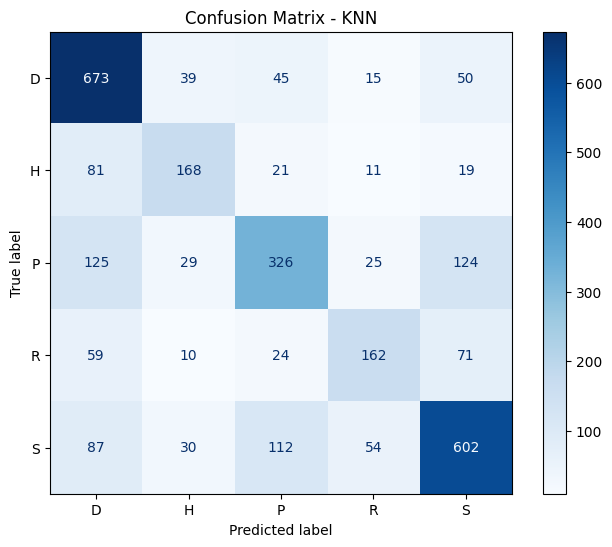

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=le.classes_,
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix - KNN")
plt.grid(False)
plt.show()

# 8.1.3 ROC AUC (Macro + Micro) (KNN)

In [ ]:
# ROC AUC scores (KNN)
y_proba_knn = knn_best.predict_proba(X_test)

roc_macro_knn = roc_auc_score(y_test, y_proba_knn, multi_class="ovr", average="macro")
roc_micro_knn = roc_auc_score(y_test, y_proba_knn, multi_class="ovr", average="micro")

print("ROC AUC Macro (KNN):", roc_macro_knn)
print("ROC AUC Micro (KNN):", roc_micro_knn)

ROC AUC Macro (KNN): 0.8469057690852786
ROC AUC Micro (KNN): 0.8610122490096249


# 8.1.4 KNN — Micro-average ROC

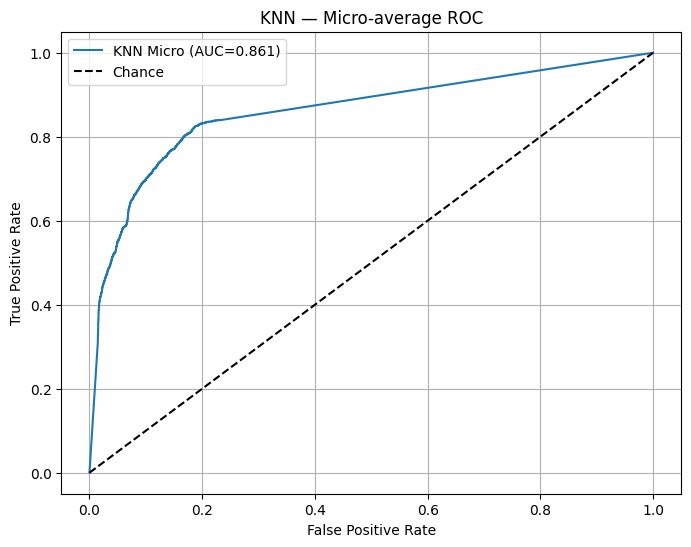

In [ ]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr_knn, tpr_knn, _ = roc_curve(y_test_bin.ravel(), y_proba_knn.ravel())
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN Micro (AUC={auc_knn:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN — Micro-average ROC")
plt.legend()
plt.grid(True)
plt.show()

# 8.1.5 KNN — Macro-average ROC

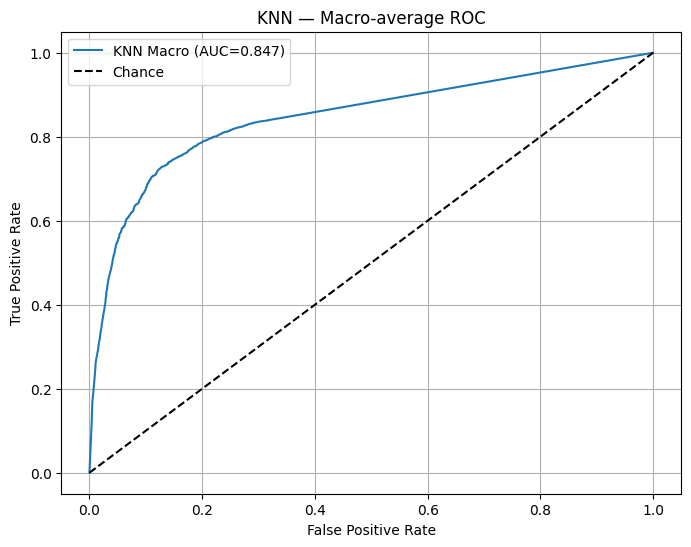

In [ ]:
# Macro-average ROC (KNN)
fpr_list, tpr_list = [], []

for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_knn[:, i])
    fpr_list.append(fpr_i)
    tpr_list.append(tpr_i)

all_fpr = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])
mean_tpr /= n_classes

macro_auc_knn = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8,6))
plt.plot(all_fpr, mean_tpr, label=f"KNN Macro (AUC={macro_auc_knn:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN — Macro-average ROC")
plt.legend()
plt.grid(True)
plt.show()

## **Section (3) :  Comparative Visualization Code**

### Plots macro-average ROC curves

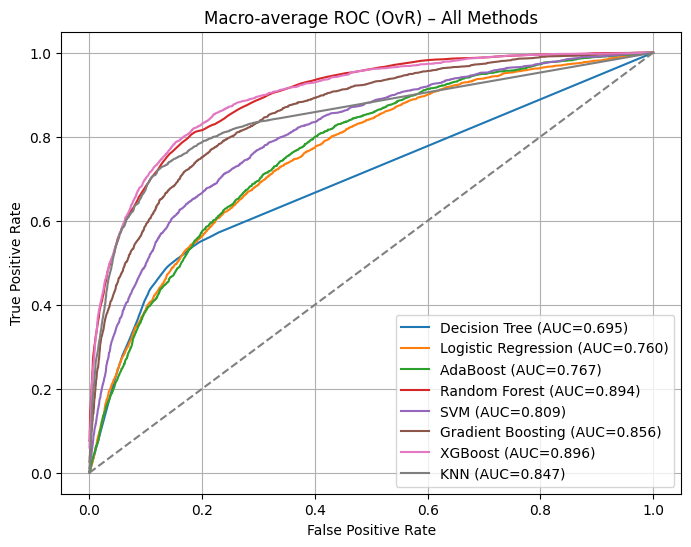

In [ ]:
def macro_roc(y_true_bin, y_proba, n_classes):
    fpr_list, tpr_list = [], []
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        fpr_list.append(fpr_i)
        tpr_list.append(tpr_i)

    all_fpr = np.unique(np.concatenate(fpr_list))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_list[i], tpr_list[i])

    mean_tpr /= n_classes
    auc_val = auc(all_fpr, mean_tpr)
    return all_fpr, mean_tpr, auc_val

models_proba = {
    "Decision Tree": y_proba_dt,
    "Logistic Regression": y_proba_lr,
    "AdaBoost": y_proba_ada,
    "Random Forest": y_proba_rf,
    "SVM": y_proba_svm,
    "Gradient Boosting": y_proba_gb,
    "XGBoost": y_proba_xgb,
    "KNN": y_proba_knn
}

plt.figure(figsize=(8,6))

for name, proba in models_proba.items():
    fpr, tpr, auc_val = macro_roc(y_test_bin, proba, n_classes)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1], [0,1], "--", color="gray")
plt.title("Macro-average ROC (OvR) – All Methods")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

### Plots micro-average ROC curves

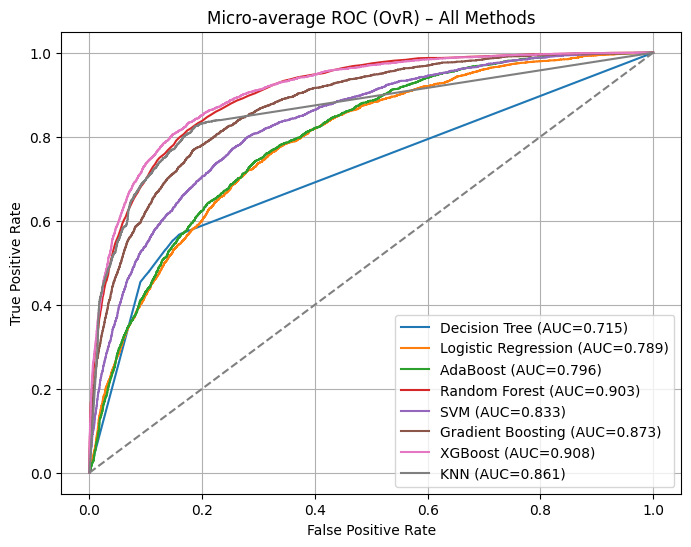

In [ ]:
def micro_roc(y_true_bin, y_proba):
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_val = auc(fpr, tpr)
    return fpr, tpr, auc_val

models_proba = {
    "Decision Tree": y_proba_dt,
    "Logistic Regression": y_proba_lr,
    "AdaBoost": y_proba_ada,
    "Random Forest": y_proba_rf,
    "SVM": y_proba_svm,
    "Gradient Boosting": y_proba_gb,
    "XGBoost": y_proba_xgb,
    "KNN": y_proba_knn
}

plt.figure(figsize=(8,6))

for name, proba in models_proba.items():
    fpr, tpr, auc_val = micro_roc(y_test_bin, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1], [0,1], "--", color="gray")
plt.title("Micro-average ROC (OvR) – All Methods")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


### Plots per-class ROC curves

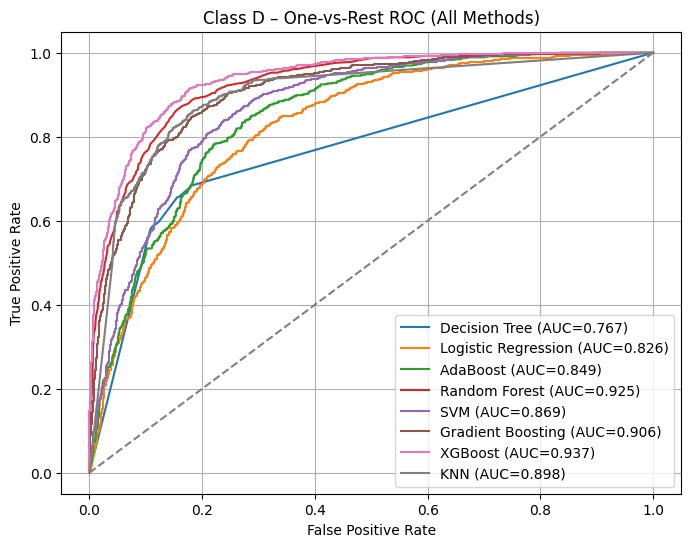

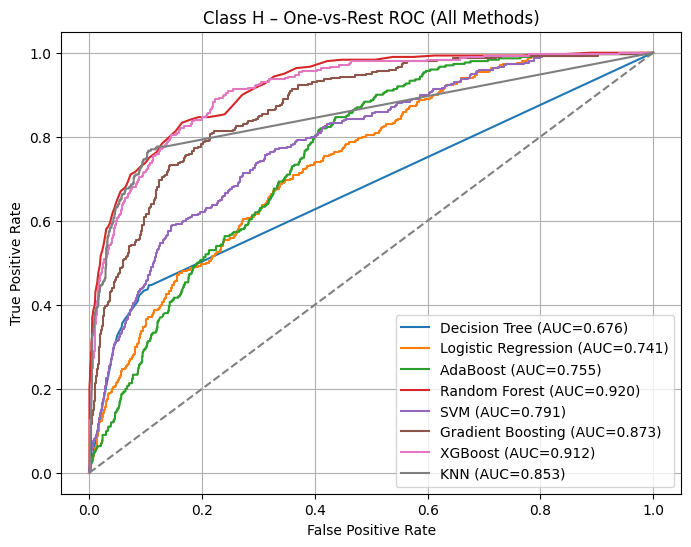

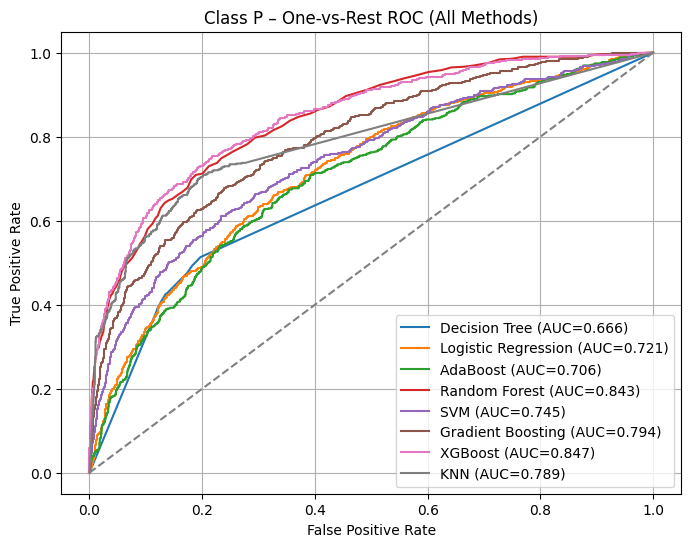

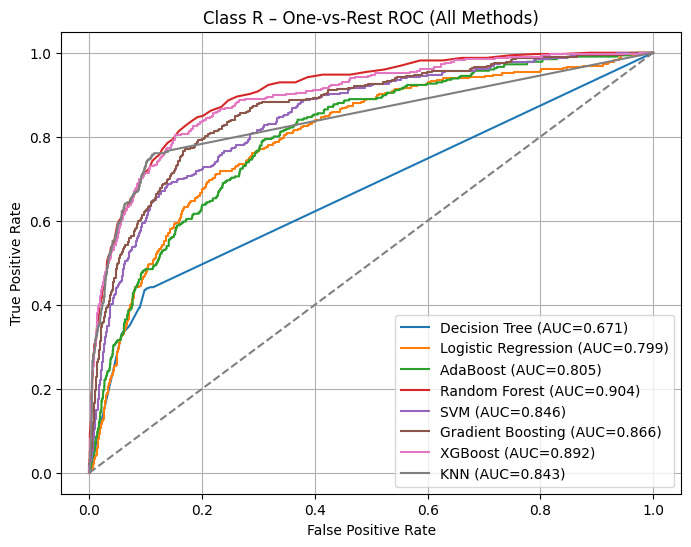

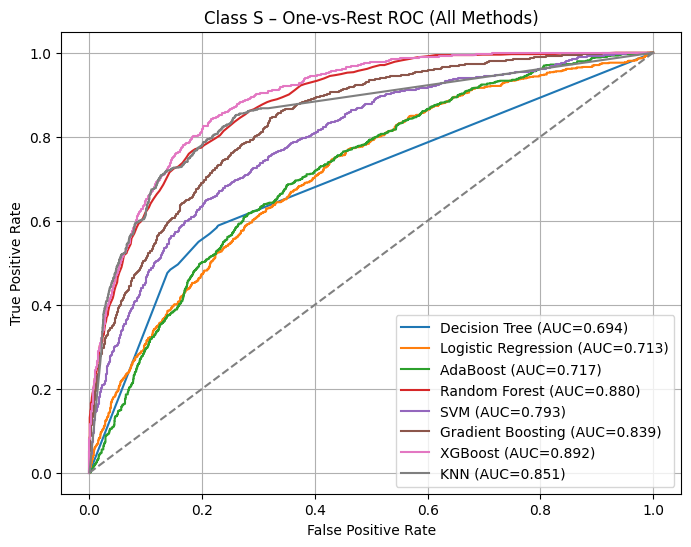

In [ ]:
for class_idx in range(n_classes):
    plt.figure(figsize=(8,6))
    class_name = le.classes_[class_idx]

    for name, proba in models_proba.items():
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

    plt.plot([0,1], [0,1], "--", color="gray")
    plt.title(f"Class {class_name} – One-vs-Rest ROC (All Methods)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


### **Summery**

In [ ]:

results_table = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "AdaBoost",
        "Random Forest",
        "SVM",
        "Gradient Boosting",
        "XGBoost",
        "KNN"
    ],
    "Balanced Accuracy": [
        bal_acc_dt,
        bal_acc_lr,
        bal_acc_ada,
        bal_acc_rf,
        bal_acc_svm,
        bal_acc_gb,
        bal_acc_xgb,
        bal_acc_knn
    ],
    "ROC AUC (Macro)": [
        roc_macro_dt,
        roc_macro_lr,
        roc_macro_ada,
        roc_macro_rf,
        roc_macro_svm,
        roc_macro_gb,
        roc_macro_xgb,
        roc_macro_knn
    ],
    "ROC AUC (Micro)": [
        roc_micro_dt,
        roc_micro_lr,
        roc_micro_ada,
        roc_micro_rf,
        roc_micro_svm,
        roc_micro_gb,
        roc_micro_xgb,
        roc_micro_knn
    ]
})

results_table = results_table.round(4)
results_table


,Model,Balanced Accuracy,ROC AUC (Macro),ROC AUC (Micro)
0,Decision Tree,0.4734,0.6948,0.7148
1,Logistic Regression,0.3582,0.7599,0.7887
2,AdaBoost,0.3907,0.7664,0.7963
3,Random Forest,0.5939,0.8941,0.9032
4,SVM,0.4693,0.8087,0.8334
5,Gradient Boosting,0.5531,0.8557,0.8727
6,XGBoost,0.6242,0.8960,0.9082
7,KNN,0.6148,0.8469,0.8610
